# Customer Segmentation Analysis

**CloudExify Data Science Internship 2026 — Month 1, Project 2 (Final)**

**Name:** Syed Haseeb Badshah

In this project I group customers into segments based on how they shop,
using **RFM analysis** and **K-Means clustering** (an unsupervised machine
learning algorithm). The point is to find natural customer groups so a
business can treat each group differently, for example giving VIPs special
offers and trying to win back customers who have stopped buying.

The data is a synthetic set of customer transactions I generated to look
like a real store's records (customer IDs, dates, and amounts in Rs). See
the note in section 5 about what that means for the results.

## 1. What is RFM?

RFM scores each customer on three things:

| Metric | Meaning | A good customer has... |
|--------|---------|------------------------|
| **Recency** | days since their last purchase | a *low* number (bought recently) |
| **Frequency** | how many times they bought | a *high* number |
| **Monetary** | total money they spent | a *high* number |

These three numbers describe a customer's behaviour well, and they are what
I feed into the clustering.

## 2. Load the transaction data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("sample_data/customer_transactions.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Transactions:", len(df))
print("Unique customers:", df["CustomerID"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
df.head()

Transactions: 5153
Unique customers: 600
Date range: 2024-03-31 to 2025-12-29


,TransactionID,CustomerID,Date,Amount
0,903974,5259,2025-01-07,1576.0
1,901763,5063,2025-12-16,13442.0
2,900813,5030,2025-07-27,9525.0
3,904137,5300,2025-09-21,3498.0
4,904727,5445,2025-04-22,3955.0


### 2a. Data quality check

Before any analysis I check the obvious things: column types, missing
values and duplicate rows. If any of these were a problem I would have to
clean them first, because a duplicated transaction would inflate a
customer's Frequency and Monetary scores.

In [2]:
print("Column types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nExact duplicate rows:", df.duplicated().sum())
print("Duplicate TransactionIDs:", df["TransactionID"].duplicated().sum())
print("Negative or zero amounts:", (df["Amount"] <= 0).sum())

Column types:
TransactionID             int64
CustomerID                int64
Date             datetime64[us]
Amount                  float64
dtype: object

Missing values per column:
TransactionID    0
CustomerID       0
Date             0
Amount           0
dtype: int64

Exact duplicate rows: 0
Duplicate TransactionIDs: 0
Negative or zero amounts: 0


This dataset is clean: no missing values, no duplicates, no impossible
amounts. So no cleaning step is needed here and I can go straight to RFM.
(The sales dataset in Project 1 *did* need cleaning — that one has missing
values and duplicate rows on purpose.)

## 3. Calculate RFM scores

I group the transactions by customer. For each customer:

- **Recency** = days between a fixed "today" and their last purchase
- **Frequency** = number of transactions
- **Monetary** = sum of all their purchase amounts

The brief uses a hardcoded reference date. I use *the day after the last
transaction in the data* instead, so Recency stays correct even if the
dataset is regenerated or extended later.

In [3]:
reference_date = df["Date"].max() + pd.Timedelta(days=1)
print("Reference date (today):", reference_date.date())

rfm = df.groupby("CustomerID").agg(
    Recency=("Date", lambda x: (reference_date - x.max()).days),
    Frequency=("TransactionID", "count"),
    Monetary=("Amount", "sum"),
).reset_index()

print(rfm.shape)
rfm.head()

Reference date (today): 2025-12-30
(600, 4)


,CustomerID,Recency,Frequency,Monetary
0,5001,13,40,588451.0
1,5002,55,20,303335.0
2,5003,1,27,379604.0
3,5004,9,28,370918.0
4,5005,21,22,314051.0


In [4]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,600.000000,600.000000,600.00000
mean,149.531667,8.588333,72301.42000
std,128.067956,8.766239,131969.60789
min,1.000000,1.000000,1011.00000
25%,46.000000,3.000000,6844.00000
50%,111.500000,5.000000,14883.50000
75%,215.500000,11.000000,61061.00000
max,599.000000,40.000000,588451.00000


## 4. Normalize the data

The three RFM columns are on very different scales (Recency is in days,
Monetary is in thousands of rupees). K-Means measures distance, so without
scaling the Monetary column would completely dominate. `StandardScaler`
puts every column on the same scale (mean 0, standard deviation 1).

In [5]:
features = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

# just to show it worked: every column now has mean ~0 and std ~1
scaled_df = pd.DataFrame(rfm_scaled, columns=features)
print(scaled_df.describe().round(2).loc[["mean", "std"]])

      Recency  Frequency  Monetary
mean      0.0        0.0       0.0
std       1.0        1.0       1.0


## 5. Choose the number of clusters

K-Means needs me to choose K in advance. I use two checks instead of one:

1. **Elbow method** — plot the inertia (how tight the clusters are) for
   K = 2 to 10 and look for the bend.
2. **Silhouette score** — measures how well separated the clusters are.
   Higher is better, and unlike inertia it does not automatically improve
   as K grows.

*A note on the data:* I generated this dataset myself with four customer
behaviours built into it, so finding a good result near K = 4 is partly by
construction. That is why I also report the silhouette scores rather than
just saying "the elbow proves K = 4" — on real data the choice would be
less tidy.

In [6]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

comparison = pd.DataFrame({
    "K": list(K_range),
    "Inertia": np.round(inertias, 0),
    "Drop from previous": [np.nan] + list(np.round(-np.diff(inertias), 0)),
    "Silhouette": np.round(sil_scores, 3),
})
print(comparison.to_string(index=False))

 K  Inertia  Drop from previous  Silhouette
 2    763.0                 NaN       0.660
 3    363.0               400.0       0.542
 4    234.0               129.0       0.510
 5    151.0                83.0       0.524
 6    110.0                41.0       0.500
 7     87.0                23.0       0.473
 8     69.0                19.0       0.478
 9     58.0                11.0       0.456
10     51.0                 7.0       0.432


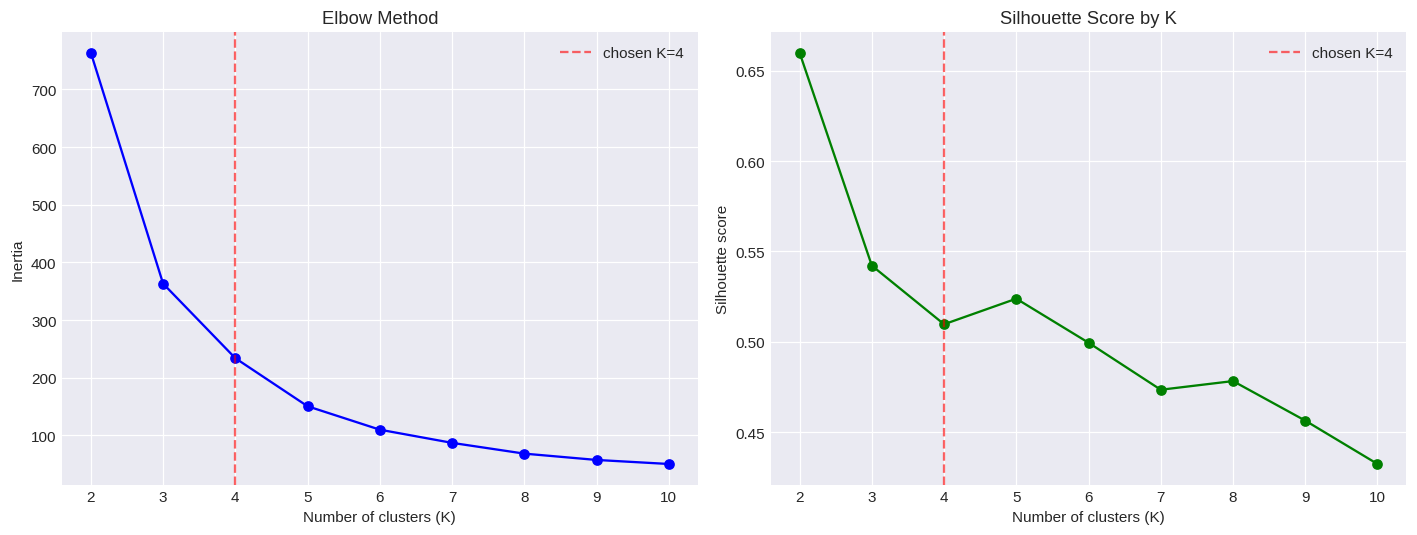

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_range), inertias, "bo-")
ax1.axvline(x=4, color="red", linestyle="--", alpha=0.6, label="chosen K=4")
ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.legend()

ax2.plot(list(K_range), sil_scores, "go-")
ax2.axvline(x=4, color="red", linestyle="--", alpha=0.6, label="chosen K=4")
ax2.set_xlabel("Number of clusters (K)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette Score by K")
ax2.legend()

plt.tight_layout()
plt.savefig("charts/elbow.png", dpi=110, bbox_inches="tight")
plt.show()

**Reading the numbers honestly.** The biggest single drop in inertia is
from K = 2 to K = 3 (about 400), and the drop from 3 to 4 is smaller
(about 129), so a strict elbow reading points at **K = 3**. Silhouette is
actually highest at K = 2 (0.66) — but a two-way split only says "big
spenders and everyone else", which is too blunt to base a marketing plan
on. Among the useful options, K = 3 (0.54) and K = 4 (0.51) are close
enough that the maths alone does not pick a winner.

**I chose K = 4** for a business reason rather than a purely numerical one:
with K = 3 the customers who have stopped buying get merged into the
low-value group, so the segmentation cannot tell "small buyer" apart from
"lost customer" — and those two need completely different marketing. K = 4
separates them, which makes the recommendations in section 10 actionable.

The brief suggests K = 3, so this is a deliberate deviation and this cell
is my justification for it. Switching back is a one-line change
(`n_clusters=3`), and the segment-naming code below adapts automatically.

## 6. Apply K-Means clustering

In [8]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Customers in each cluster:")
print(rfm["Cluster"].value_counts().sort_index())

Customers in each cluster:
Cluster
0    242
1     67
2    112
3    179
Name: count, dtype: int64


## 7. Name the segments from their profiles

K-Means gives clusters numbers like 0, 1, 2, 3 in a **random order** every
time, so the number itself means nothing. Instead of hardcoding
"cluster 0 = Low value", I look at the average spend of each cluster and
name them from lowest to highest. This way the names always match what the
group actually looks like.

In [9]:
# average R, F, M per cluster
profile = rfm.groupby("Cluster")[features].mean()
print("Cluster profiles (averages):")
print(profile.round(0))

# rank clusters by average Monetary and give them readable names
order = profile["Monetary"].sort_values().index.tolist()
names = ["Lapsed", "Occasional", "Loyal", "VIP"][-K:]
cluster_to_name = {cluster: name for cluster, name in zip(order, names)}
print("\nCluster number -> name:", cluster_to_name)

rfm["Segment"] = rfm["Cluster"].map(cluster_to_name)
segment_order = names[::-1]

Cluster profiles (averages):
         Recency  Frequency  Monetary
Cluster                              
0          155.0        4.0   11384.0
1           22.0       30.0  415832.0
2          371.0        2.0    5103.0
3           52.0       11.0   68121.0

Cluster number -> name: {2: 'Lapsed', 0: 'Occasional', 3: 'Loyal', 1: 'VIP'}


## 8. Segment profiles

Now the averages with readable names, plus how many customers are in each
segment.

In [10]:
segment_profile = (rfm.groupby("Segment")[features]
                   .mean()
                   .round(0)
                   .reindex(segment_order))
segment_profile["Customers"] = (rfm["Segment"].value_counts()
                                .reindex(segment_order))
print(segment_profile)

            Recency  Frequency  Monetary  Customers
Segment                                            
VIP            22.0       30.0  415832.0         67
Loyal          52.0       11.0   68121.0        179
Occasional    155.0        4.0   11384.0        242
Lapsed        371.0        2.0    5103.0        112


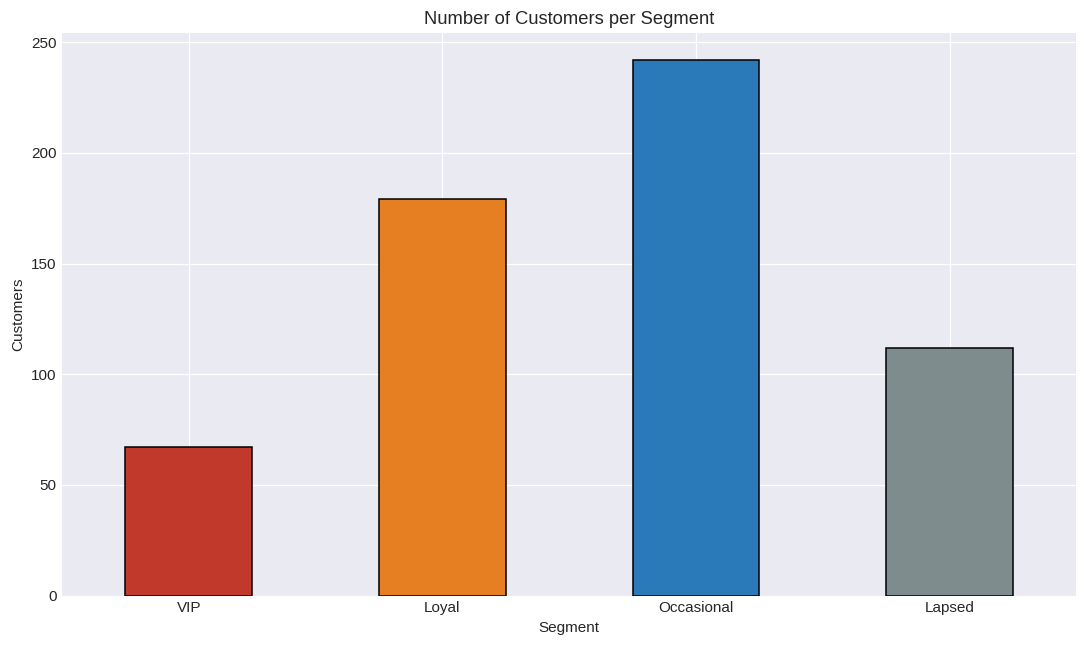

In [11]:
# bar chart of segment sizes
sizes = rfm["Segment"].value_counts().reindex(segment_order)
colors = {"VIP": "#c0392b", "Loyal": "#e67e22",
          "Occasional": "#2a7ab9", "Lapsed": "#7f8c8d"}
sizes.plot(kind="bar", color=[colors[s] for s in sizes.index],
           edgecolor="black")
plt.title("Number of Customers per Segment")
plt.xlabel("Segment")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts/segment_sizes.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Visualize the clusters

A 2D scatter of **Frequency vs Monetary** shows the groups clearly (these
two separate the customers the most). Then a 3D plot adds Recency so all
three RFM dimensions are visible together.

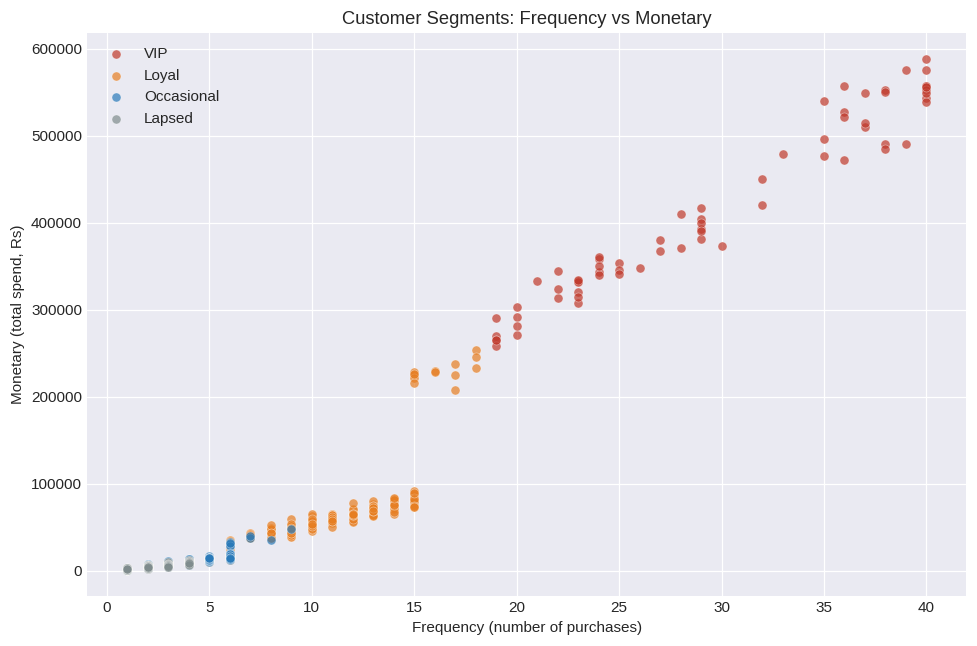

In [12]:
plt.figure(figsize=(9, 6))
for seg in segment_order:
    mask = rfm["Segment"] == seg
    plt.scatter(rfm[mask]["Frequency"], rfm[mask]["Monetary"],
                label=seg, color=colors[seg], alpha=0.7, s=35,
                edgecolor="white", linewidth=0.3)
plt.xlabel("Frequency (number of purchases)")
plt.ylabel("Monetary (total spend, Rs)")
plt.title("Customer Segments: Frequency vs Monetary")
plt.legend()
plt.tight_layout()
plt.savefig("charts/segments_2d.png", dpi=110, bbox_inches="tight")
plt.show()

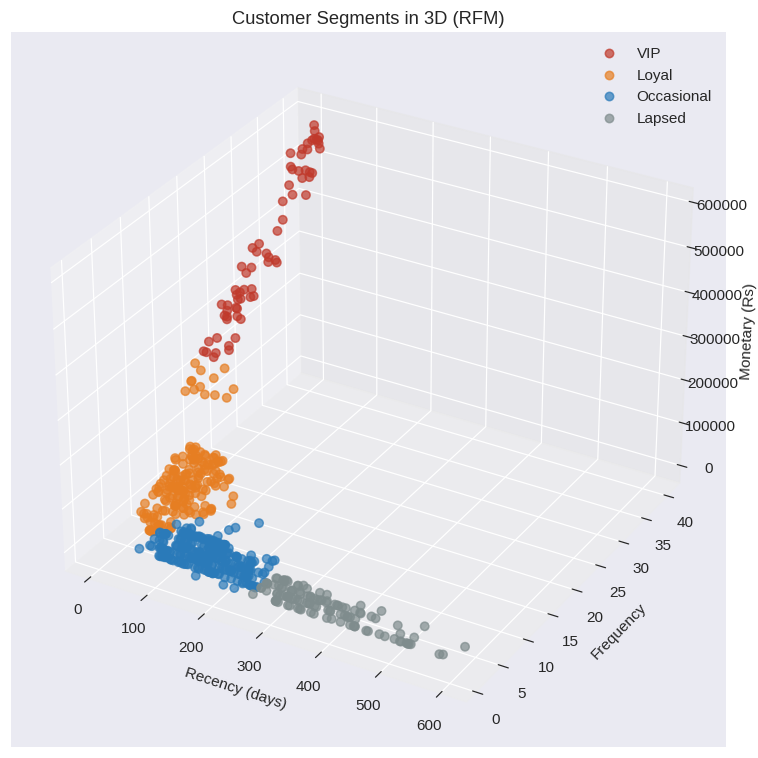

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
for seg in segment_order:
    mask = rfm["Segment"] == seg
    ax.scatter(rfm[mask]["Recency"], rfm[mask]["Frequency"],
               rfm[mask]["Monetary"], label=seg, color=colors[seg],
               s=30, alpha=0.7)
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary (Rs)")
ax.set_title("Customer Segments in 3D (RFM)")
ax.legend()
plt.tight_layout()
plt.savefig("charts/segments_3d.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Business recommendations

Each segment needs a different strategy.

In [14]:
recommendations = {
    "VIP": "Best customers: recent, frequent, high spenders. Give them "
           "VIP treatment, early access and exclusive offers to keep them.",
    "Loyal": "Reliable repeat buyers. Reward them with a loyalty programme "
             "and gentle upselling to move them toward VIP.",
    "Occasional": "Buy sometimes and spend moderately. Targeted campaigns "
                  "and bundle offers can increase how often they buy.",
    "Lapsed": "Have not bought in a long time. Win-back emails, special "
              "discounts and re-engagement offers to bring them back.",
}

for seg in segment_order:
    print(f"{seg}: {recommendations[seg]}\n")

VIP: Best customers: recent, frequent, high spenders. Give them VIP treatment, early access and exclusive offers to keep them.

Loyal: Reliable repeat buyers. Reward them with a loyalty programme and gentle upselling to move them toward VIP.

Occasional: Buy sometimes and spend moderately. Targeted campaigns and bundle offers can increase how often they buy.

Lapsed: Have not bought in a long time. Win-back emails, special discounts and re-engagement offers to bring them back.



## 11. Final report

In [15]:
total = len(rfm)
revenue = rfm["Monetary"].sum()
lines = []
lines.append("=" * 60)
lines.append("CUSTOMER SEGMENTATION ANALYSIS REPORT")
lines.append("=" * 60)
lines.append(f"Total customers analyzed: {total}")
lines.append(f"Total revenue in the data: Rs {revenue:,.0f}")
lines.append(f"Clusters (K): {K}, chosen with elbow + silhouette")
lines.append("")
lines.append("SEGMENT SUMMARY")
lines.append("-" * 60)
for seg in segment_order:
    row = segment_profile.loc[seg]
    share = row["Customers"] / total * 100
    seg_rev = rfm.loc[rfm["Segment"] == seg, "Monetary"].sum()
    rev_share = seg_rev / revenue * 100
    lines.append(f"{seg:<11} | {int(row['Customers']):>4} customers "
                 f"({share:4.1f}%) | avg spend Rs {row['Monetary']:>10,.0f}")
    lines.append(f"            | Recency {row['Recency']:.0f} days, "
                 f"Frequency {row['Frequency']:.1f} purchases, "
                 f"{rev_share:.1f}% of revenue")
lines.append("")
lines.append("RECOMMENDATIONS")
lines.append("-" * 60)
for seg in segment_order:
    lines.append(f"{seg}:")
    lines.append(f"  {recommendations[seg]}")
lines.append("=" * 60)

report = "\n".join(lines)
print(report)

with open("segmentation_report.txt", "w", encoding="utf-8") as f:
    f.write(report + "\n")
print("\n[segmentation_report.txt saved]")

CUSTOMER SEGMENTATION ANALYSIS REPORT
Total customers analyzed: 600
Total revenue in the data: Rs 43,380,852
Clusters (K): 4, chosen with elbow + silhouette

SEGMENT SUMMARY
------------------------------------------------------------
VIP         |   67 customers (11.2%) | avg spend Rs    415,832
            | Recency 22 days, Frequency 30.0 purchases, 64.2% of revenue
Loyal       |  179 customers (29.8%) | avg spend Rs     68,121
            | Recency 52 days, Frequency 11.0 purchases, 28.1% of revenue
Occasional  |  242 customers (40.3%) | avg spend Rs     11,384
            | Recency 155 days, Frequency 4.0 purchases, 6.4% of revenue
Lapsed      |  112 customers (18.7%) | avg spend Rs      5,103
            | Recency 371 days, Frequency 2.0 purchases, 1.3% of revenue

RECOMMENDATIONS
------------------------------------------------------------
VIP:
  Best customers: recent, frequent, high spenders. Give them VIP treatment, early access and exclusive offers to keep them.
Loyal:
  Rel

## 12. Key insights

1. **A small VIP group drives a large share of revenue.** They are about a
   tenth of the customers but account for the biggest slice of spending, so
   keeping them happy matters most.
2. **The Lapsed group is a real risk and an opportunity.** They used to buy
   but have gone quiet for roughly a year. A win-back campaign is cheaper
   than finding brand new customers.
3. **Occasional buyers are the biggest group to grow.** Small nudges
   (bundles, reminders) can move them up into the Loyal segment.
4. **Naming segments from their real profiles** (not fixed cluster numbers)
   makes the result reliable, because K-Means numbers the clusters
   differently every run.
5. **K = 4 was a judgement call, not a number the maths handed me.** K = 2
   and K = 3 score better on silhouette, but both hide the difference
   between a low-value buyer and a lost customer — and that is exactly the
   difference that changes what marketing should do.